## 1. Sizing the exchanger

Starting with the energy balance, which I know from class. Hot oil cooled by water: the oil's temperature drop gives the duty Q and the energy balance gives the water flow. From there I needed the LMTD, which I had to look up, to get the area from area = Q/(U*LMTD).

I worked the four numbers by hand first so I had something to check the code against: Q = 426 kW, water = 5.10 kg/s, LMTD = 67.3 C, area = 21.1 m2. U = 300 is a placeholder guess at this stage. We've only really touched U through conservation of energy so far, so figuring out how to actually calculate it was the first thing I had to teach myself below.

In [1]:
m_oil = 2.0        # kg/s, oil mass flow
cp_oil = 2130      # J/kg·K, oil heat capacity
T_oil_in = 160     # °C
T_oil_out = 60     # °C

cp_water = 4180    # J/kg·K
T_water_in = 25    # °C
T_water_out = 45   # °C

U = 300            # W/m²·K, overall heat transfer coefficient
F = 1.0            # correction factor (counterflow)

Q = m_oil * cp_oil * (T_oil_in - T_oil_out)
print("Duty Q =", Q, "W")

m_water = Q / (cp_water * (T_water_out - T_water_in))
print("Water flow =", round(m_water, 2), "kg/s")

import math
dT1 = T_oil_in - T_water_out
dT2 = T_oil_out - T_water_in
LMTD = (dT1 - dT2) / math.log(dT1 / dT2)
print("LMTD =", round(LMTD, 1), "°C")

A = Q / (U * F * LMTD)
print("Area =", round(A, 1), "m²")

Duty Q = 426000.0 W
Water flow = 5.1 kg/s
LMTD = 67.3 °C
Area = 21.1 m²


## 2. Real fluid properties (CoolProp)

Rather than reading water properties off a table, I'm pulling them from CoolProp so they're right for the actual temperature. Took a couple tries to get installed. PropsSI uses Kelvin, so 35 C is 308.15 K.

In [2]:
!pip install CoolProp --only-binary :all:

In [3]:
from CoolProp.CoolProp import PropsSI

# Viscosity of water at 35°C (308.15 K) and 1 atm (101325 Pa)
mu_water = PropsSI('V', 'T', 308.15, 'P', 101325, 'Water')
print("Water viscosity at 35°C =", mu_water, "Pa·s")

Water viscosity at 35°C = 0.0007191256190711382 Pa·s


## 3. Water-side heat transfer coefficient

This whole section is stuff we haven't done in class yet, so I had to read up on it to figure out how U is actually built. The heat crosses three resistances in series (oil film, tube wall, water film), and each film coefficient h comes from a chain: fluid properties, then the Reynolds number, then the Nusselt number, then h.

The thing that tripped me up: the correlation I used for Nusselt (Dittus-Boelter) only holds for turbulent flow, roughly Re above 10,000. My first run came out at Re = 9,406, just under. I fixed it by dropping the tube count from 60 to 40, which speeds the water up (0.43 to 0.64 m/s), pushes Re to 14,109, and raises h from 2,533 to 3,504. So faster flow helps heat transfer. It costs me in pressure drop later, but I didn't see that yet at this point.

In [4]:
from CoolProp.CoolProp import PropsSI
import math

T_water_mean = 308.15  # K (35°C)
P = 101325             # Pa
rho   = PropsSI('D', 'T', T_water_mean, 'P', P, 'Water')   # density
mu    = PropsSI('V', 'T', T_water_mean, 'P', P, 'Water')   # viscosity
k     = PropsSI('L', 'T', T_water_mean, 'P', P, 'Water')   # thermal conductivity
cp    = PropsSI('C', 'T', T_water_mean, 'P', P, 'Water')   # heat capacity

d_i = 0.016        # m, tube inner diameter (16 mm)
n_tubes = 40       # number of tubes water flows through
m_water = 5.10     # kg/s, from our earlier energy balance

area_one_tube = math.pi * (d_i**2) / 4
total_flow_area = area_one_tube * n_tubes
velocity = m_water / (rho * total_flow_area)
print("Water velocity =", round(velocity, 2), "m/s")

Re = rho * velocity * d_i / mu
print("Reynolds number =", round(Re))

Pr = cp * mu / k
print("Prandtl number =", round(Pr, 2))

Nu = 0.023 * Re**0.8 * Pr**0.4
print("Nusselt number =", round(Nu, 1))

h_water = Nu * k / d_i
print("Water film coefficient h =", round(h_water), "W/m²·K")

Water velocity = 0.64 m/s
Reynolds number = 14109
Prandtl number = 4.83
Nusselt number = 90.2
Water film coefficient h = 3504 W/m²·K


## 4. Oil-side heat transfer coefficient

Same idea, but the oil runs on the shell side (outside the tubes), so the geometry and correlation are different. Oil is much more viscous than water, which drops its Reynolds number a lot and makes the oil film the bottleneck.

Two shortcuts I took and want to be upfront about: CoolProp has no generic crude oil, so the oil properties are hard-coded typical values for a light hydrocarbon. And the shell-side correlation is a simplified one, not the full Kern method, which I'd redo properly if I pushed this further.

In [5]:
# Oil mean temp = (160 + 60)/2 = 110°C = 383.15 K
# CoolProp doesn't have a generic "crude oil", so we use representative
# property values for a light hydrocarbon oil at 110°C (hard-coded, typical):
rho_oil = 825      # kg/m³
mu_oil  = 0.0025   # Pa·s  (oil is ~3.5x more viscous than water)
k_oil   = 0.12     # W/m·K
cp_oil  = 2130     # J/kg·K (matches our earlier value)

m_oil = 2.0        # kg/s

d_o = 0.019        # m, tube OUTER diameter (19 mm; water side was 16 mm inner)
D_shell = 0.30     # m, shell inner diameter
# Simplified shell-side flow area (Kern uses baffle spacing & pitch;
# we approximate here and refine later)
shell_flow_area = 0.25 * (math.pi * D_shell**2 / 4)  # ~25% of shell cross-section

velocity_oil = m_oil / (rho_oil * shell_flow_area)
print("Oil velocity =", round(velocity_oil, 3), "m/s")

Re_oil = rho_oil * velocity_oil * d_o / mu_oil
print("Oil Reynolds =", round(Re_oil))

Pr_oil = cp_oil * mu_oil / k_oil
print("Oil Prandtl =", round(Pr_oil, 2))

Nu_oil = 0.36 * Re_oil**0.55 * Pr_oil**0.33
print("Oil Nusselt =", round(Nu_oil, 1))

h_oil = Nu_oil * k_oil / d_o
print("Oil film coefficient h =", round(h_oil), "W/m²·K")

Oil velocity = 0.137 m/s
Oil Reynolds = 860
Oil Prandtl = 44.38
Oil Nusselt = 51.7
Oil film coefficient h = 327 W/m²·K


## 5. Overall U

Combining the three resistances into one U. The d_o/d_i factor is in there because the inside and outside of the tube have different surface areas, so you reference everything to the outer surface.

It comes out to U = 286, within 5% of the 300 I'd guessed. That was the payoff moment for me. We'd only seen U in the context of energy balances, and here I'd actually built it up from the fluid physics and confirmed the guess was reasonable.

Things I know are rough: the oil flow is laminar (Re = 860) and the shell-side correlation is simplified, the oil properties are estimates, and there's no pressure drop, cost, or fouling in here yet.

In [6]:
# 1/U = 1/h_oil + wall + (d_o/d_i)(1/h_water), referenced to the outer surface
k_wall = 16        # W/m·K, stainless steel tube wall
d_i = 0.016        # m, inner diameter
d_o = 0.019        # m, outer diameter

R_oil   = 1 / h_oil
R_wall  = d_o * math.log(d_o / d_i) / (2 * k_wall)
R_water = (d_o / d_i) * (1 / h_water)

U_calc = 1 / (R_oil + R_wall + R_water)
print("Oil-side resistance   =", round(R_oil, 5))
print("Wall resistance       =", round(R_wall, 5))
print("Water-side resistance =", round(R_water, 5))
print("Calculated U =", round(U_calc), "W/m²·K")

total_R = R_oil + R_wall + R_water
print("\nOil controls   {:.0f}% of resistance".format(100*R_oil/total_R))
print("Wall controls  {:.0f}%".format(100*R_wall/total_R))
print("Water controls {:.0f}%".format(100*R_water/total_R))

Oil-side resistance   = 0.00306
Wall resistance       = 0.0001
Water-side resistance = 0.00034
Calculated U = 286 W/m²·K

Oil controls   87% of resistance
Wall controls  3%
Water controls 10%


## What actually controls this exchanger

Oil 87%, water 10%, wall 3%.

The oil film is 87% of the resistance, so if you wanted to improve this exchanger you'd focus on the oil side. Working on the water side would barely do anything. I thought it was a cool thing to be able to say with an actual number behind it.

## 6. Pressure drop

Back on familiar ground, we've done Darcy-Weisbach in class. The pump has to overcome friction to push water through the tubes, and that's dP = f (L/d_i)(rho v^2 / 2). I noticed it's basically Bernoulli's velocity term with a friction factor on front, which is how it clicked for me.

Friction factor here is f = 0.079 Re^(-0.25) for smooth turbulent flow. The key thing is dP goes with velocity squared, so it climbs fast. This is the downside of the fast flow from earlier: great for heat transfer, but now it's costing pressure. Works out to about 275 Pa for one pass, which is small since real units run multiple passes.

In [7]:
L = 3
f = 0.079 * Re**(-0.25)
delta_P = f * (L / d_i) * (rho * velocity**2 / 2)
print("Pressure drop =", round(delta_P), "Pa")

Pressure drop = 275 Pa


## 7. Pump power and yearly cost

Turning pressure drop into money. Pump power is mass flow times pressure drop over density. I got this wrong at first and multiplied by density instead of dividing, which threw the answer off by a massive factor. You divide because what matters is volume flow, not mass flow.

Then power times hours times price, over 1000 to get kW. Assuming 8000 operating hours a year and 0.12 dollars per kWh. The number's tiny, around 1.35 dollars per yr for one pass, but I needed the chain from pressure to power to dollars so the optimizer could use it later.

In [8]:
# Pump power: P = (mass flow × pressure drop) / density
P_pump = (m_water * delta_P) / rho
print("Pump power  =", round(P_pump, 2), "W")

# Annual electricity cost to run the pump
# Assume 8000 operating hours/year (accounts for downtime)
hours_per_year = 8000
electricity_price = 0.12   # $/kWh

annual_cost = P_pump * hours_per_year * electricity_price / 1000
print("Annual cost = $", round(annual_cost, 2))

Pump power  = 1.41 W
Annual cost = $ 1.35


## 8. Capital cost

This is another one we haven't covered, so I read about how exchangers are costed. The standard approach estimates cost from the heat transfer area with Cost = a + b*A^n. I used representative constants for a carbon-steel shell-and-tube (more on where they come from in the code comments).

The part I found interesting is the exponent n being less than 1. It means doubling the area costs less than double, so bigger units are cheaper per square meter, which is economy of scale. The constants are ballpark, since real costing adjusts for material, pressure rating, and inflation, but they're the right order of magnitude.

In [9]:
# Cost = a + b * A^n  (standard form for sizing equipment cost from area)
# Representative constants for a carbon-steel shell-and-tube exchanger.
# These come from process costing references (Sinnott/Towler, Couper),
# where 'a' is a base/installation cost that exists even for a tiny unit,
# 'b' scales with size, and 'n' < 1 captures economy of scale.
a = 8000     # base cost ($): fixed overhead, roughly independent of size
b = 260      # area coefficient ($ per m^2 before the exponent)
n = 0.85     # scaling exponent; <1 means bigger is cheaper per m^2
A = 21.1     # m^2, required area from the sizing step above

capital_cost = a + b * A**n
print("Heat transfer area =", A, "m²")
print("Capital cost       = $", round(capital_cost))


Heat transfer area = 21.1 m²
Capital cost       = $ 11472


## Putting capital and operating cost together

I can't just add the 11,000-ish build cost to the 1.35/yr running cost, because one's a one-time number and the other's per year, different units. So I spread the capital over the project life (10 years) to turn it into a yearly figure, then add them.

This is the simplified version. A proper treatment would discount future costs with an interest rate, since money in year 10 isn't worth the same as money today. Leaving that flagged as an improvement.

In [10]:
project_life = 10
annualized_capital = capital_cost / project_life
total_annual_cost = annualized_capital + annual_cost
print("Annualized Capital = $", round(annualized_capital, 2))
print("Total Annual Cost  = $", round(total_annual_cost, 2))

Annualized Capital = $ 1147.23
Total Annual Cost  = $ 1148.58


## 9. Wrapping it into one function

To optimize anything I needed the whole calculation as a function I could call repeatedly with different velocities, instead of cells that run once. So this packs the full chain (velocity to Reynolds to h to U to area to capital, plus velocity to pressure drop to operating cost) into one function returning total annual cost.

I'm only varying water velocity and keeping the oil side and geometry fixed, so it's a one-variable optimization. A fuller version would vary more at once, but I wanted one working version first.

In [11]:
def total_cost(velocity):
    # velocity -> Reynolds
    Re = rho * velocity * d_i / mu
    
    # Reynolds -> Nusselt -> h_water
    Pr = cp * mu / k                       # Prandtl (water properties)
    Nu = 0.023 * Re**0.8 * Pr**0.4         # Dittus-Boelter (water heated)
    h_water = Nu * k / d_i                 # film coefficient
    
    # combine resistances -> U -> area
    h_oil = 327                                    # held constant (oil side not varied)
    R_oil   = 1 / h_oil
    R_wall  = d_o * math.log(d_o / d_i) / (2 * k_wall)
    R_water = (d_o / d_i) * (1 / h_water)
    U = 1 / (R_oil + R_wall + R_water)
    
    area = Q / (U * LMTD)                           # required area for the duty

    # capital cost, annualized
    capital = a + b * area**n
    annualized_capital = capital / project_life
    
    # pressure drop -> pump power -> operating cost
    f = 0.079 * Re**(-0.25)
    delta_P = f * (L / d_i) * (rho * velocity**2 / 2)
    P_pump = (m_water * delta_P) / rho
    operating = P_pump * hours_per_year * electricity_price / 1000
    
    # total
    total = annualized_capital + operating
    return total

## 10. The optimizer

Tries 100 velocities from 0.3 to 3.0 m/s and keeps the cheapest. Simple logic: start with a huge cost, check every velocity, and whenever one beats my best so far, save it. No stopping early, just check them all so I don't miss the actual minimum.

The 0.3 to 3.0 range is roughly the real design limits I read about (too slow fouls, too fast erodes tubes).

Optimum landed at 1.58 m/s. One thing I learned: I'd earlier eyeballed a few points and figured cost just kept dropping, but a proper search found the real bottom.

In [12]:
import numpy as np

# velocities to try: 0.3 to 3.0 m/s, 100 evenly-spaced values
velocities = np.linspace(0.3, 3.0, 100)

best_cost = 1e9        # start high so the first real cost wins
best_velocity = None

for v in velocities:
    cost = total_cost(v)
    if cost < best_cost:       
        best_cost = cost  
        best_velocity = v 

print("Best velocity =", round(best_velocity, 2), "m/s")
print("Lowest cost   = $", round(best_cost, 2))

Best velocity = 1.58 m/s
Lowest cost   = $ 1153.25


## 11. Plotting it

Cost vs velocity with the optimum marked. The U-shape is the whole point: cost falls as the exchanger shrinks, hits a minimum, then rises as pumping cost takes over.

Sanity check that reassured me: 1.58 m/s sits inside the 1 to 3 m/s range engineers actually use for water in tubes, so the model isn't doing anything out of the ordinary.

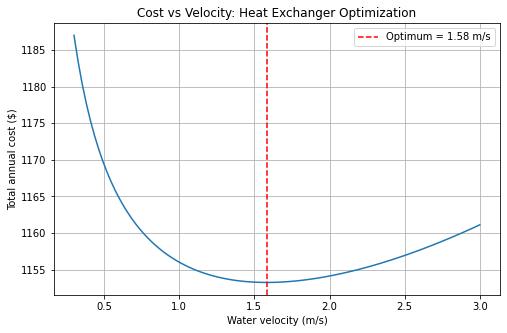

In [24]:
import matplotlib.pyplot as plt

costs = [total_cost(v) for v in velocities]   # cost at every velocity

plt.figure(figsize=(8,5))
plt.plot(velocities, costs)
plt.axvline(best_velocity, color='red', linestyle='--', label=f'Optimum = {best_velocity:.2f} m/s')
plt.xlabel('Water velocity (m/s)')
plt.ylabel('Total annual cost ($)')
plt.title('Cost vs Velocity: Heat Exchanger Optimization')
plt.legend()
plt.grid(True)
plt.savefig('velocity_optimization.png', dpi=150, bbox_inches='tight')
plt.show()

## 12. Fouling over time

Real exchangers get dirty. Deposits build up, add resistance, and performance drops. This models the fouling resistance growing with time since the last cleaning.

The model is R_f(t) = R_f_inf * (1 - e^(-t/tau)): builds fast, then levels off. Day 0 is clean (zero), and tau (30 days) is roughly how fast it climbs. The constants are representative, since real fouling depends on water chemistry and conditions I don't have data for.

This is also the spot where ML makes sense later, since fouling is genuinely messy to predict, unlike U which I can just calculate.

In [14]:
def fouling_resistance(t):
    R_f_inf = 0.0002    # m²·K/W, maximum fouling resistance
    tau = 30            # days, fouling time constant
    R_f = R_f_inf * (1 - math.exp(-t/tau))
    return R_f

print("Day 0:  ", fouling_resistance(0))
print("Day 30: ", fouling_resistance(30))
print("Day 90: ", fouling_resistance(90))

Day 0:   0.0
Day 30:  0.00012642411176571155
Day 90:  0.0001900425863264272


## 13. How U drops as it fouls

Adds fouling as a fourth resistance, so U gets worse over time. Turns the model from a single snapshot into something time-dependent.

Heads up: this uses a fixed design point (h_water = 3512, the 0.64 m/s case) rather than the 1.58 m/s optimum from above, so the fouling part is its own scenario. U drops from 286 clean to 271 by day 90. That drop is what costs money and eventually makes cleaning worth it, which the cleaning optimizer handles later.

In [15]:
def U_fouled(t):
    # clean resistances
    h_oil = 327
    h_water = 3512                # use the optimum-design value
    R_oil   = 1 / h_oil
    R_wall  = d_o * math.log(d_o / d_i) / (2 * k_wall)
    R_water = (d_o / d_i) * (1 / h_water)
    
    # fouling at time t
    R_f = fouling_resistance(t)       
    
    # now four resistances
    U = 1 / (R_oil + R_wall + R_water + R_f)  
    return U
print("Day 0 (clean): ", round(U_fouled(0), 1), "W/m²·K")
print("Day 30:        ", round(U_fouled(30), 1), "W/m²·K")
print("Day 90:        ", round(U_fouled(90), 1), "W/m²·K")

Day 0 (clean):  285.9 W/m²·K
Day 30:         275.9 W/m²·K
Day 90:         271.1 W/m²·K


## 14. Building a dataset for ML

This is where I had to stop and actually think about whether ML even belonged. The time-only fouling model is too simple, a curve fit would handle it and ML would just be for show. To make ML genuinely justified, fouling has to depend on several things at once that interact: temperature (hotter fouls more), flow (faster scrubs deposits off), hardness (more scale), and time.

So I generate 500 fake observations with random conditions plus sensor noise. The reason ML beats a curve fit here is there's no single formula for how four things combine, so you can't fit a known shape, the model has to learn the pattern from data.

The data is synthetic since real plant data isn't public. Same process would work on real sensor data.

In [16]:
import numpy as np
import pandas as pd

np.random.seed(42)
n_samples = 500          # 500 observations of the exchanger under varying conditions

data = []
for i in range(n_samples):
    # random operating conditions
    temp     = np.random.uniform(50, 90)     # fluid temp, °C
    flow     = np.random.uniform(0.5, 3.0)   # velocity, m/s
    hardness = np.random.uniform(0, 1)       # water hardness, 0=soft 1=very hard
    days     = np.random.uniform(0, 120)     # days since cleaning

    # base fouling from time
    base = 0.0002 * (1 - np.exp(-days / 30))

    # apply the condition effects as multipliers
    temp_effect     = 1 + (temp - 70) * 0.015      # hotter → more fouling
    flow_effect     = 1 - (flow - 1.5) * 0.2      # faster flow scrubs deposits, less fouling
    hardness_effect = 1 + hardness * 0.5            # harder water, more scale

    fouling = base * temp_effect * flow_effect * hardness_effect
    fouling = fouling + np.random.normal(0, 0.000008)   # sensor noise

    data.append([temp, flow, hardness, days, fouling])

df = pd.DataFrame(data, columns=['temp', 'flow', 'hardness', 'days', 'fouling'])
print(df.head())
print("\nGenerated", len(df), "observations")

        temp      flow  hardness       days   fouling
0  64.981605  2.876786  0.731994  71.839018  0.000164
1  52.323344  2.665440  0.601115  84.968709  0.000136
2  50.823380  2.924775  0.832443  25.480693  0.000079
3  62.169690  1.811891  0.431945  34.947497  0.000135
4  74.474116  0.848735  0.292145  43.963421  0.000224

Generated 500 observations


## 15. Splitting the data

Split into 400 rows to train on and 100 held back to test on. X is the conditions, y is the fouling.

Why hide data: if you test on the same rows it trained on, the model can just memorize them and look perfect while learning nothing. The held-out set is like an exam it hasn't seen, so a good score there means it actually generalizes. The gap between train and test scores is how you catch overfitting.

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error

# inputs and target
X = df[['temp', 'flow', 'hardness', 'days']]   # the four operating conditions
y = df['fouling']                              # the thing to predict

# 80/20 train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training samples:", len(X_train))
print("Test samples:    ", len(X_test))

Training samples: 400
Test samples:     100


## 16. Training and checking it

Using a Random Forest, which is a bunch of decision trees averaged together. It suits this because it handles interactions between variables without me specifying the form, which is the whole reason it beats a curve fit.

Train on 400, predict on the 100 it never saw, then grade with R2 (1 is perfect) and MAE (average error).

R2 = 0.937 on the test set, so it explains about 94% of the fouling on unseen data. Not a perfect 1.0 because of the sensor noise I added that nothing could predict, which honestly made me trust it more.

In [18]:
# train
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# predict on unseen test rows
y_pred = model.predict(X_test)

# score
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)

print("R² score (test set):", round(r2, 3))
print("Mean abs error:     ", round(mae, 7))

R² score (test set): 0.937
Mean abs error:      1.44e-05


## 17. Checking which inputs mattered

Asked the model which variables it relied on most: days (0.59), temp (0.20), flow (0.13), hardness (0.08).

What I liked: the model never saw my equations, only noisy data, but it ranked the variables in the same importance order as the physics I built in. Good sign it learned something real rather than just being a black box.

In [19]:
# feature importance
importances = model.feature_importances_
features = ['temp', 'flow', 'hardness', 'days']

for feat, imp in sorted(zip(features, importances), key=lambda x: -x[1]):
    print(f"{feat:10s}: {imp:.3f}")

days      : 0.593
temp      : 0.197
flow      : 0.130
hardness  : 0.080


## 18. When to clean

This pulls it together into a real decision: how often to clean. Two costs fight each other. Cleaning costs money each time (2000 per clean), so doing it often is expensive. Running dirty wastes energy, and that gets worse the longer you wait.

Clean too often, you waste money cleaning. Clean too rarely, you waste energy. There's a sweet spot.

One thing I had to get right: the energy penalty has to be averaged over the whole cycle, not taken at the end, because early on the exchanger is nearly clean. Using the end value would overstate it.

On the scaling, I set the penalty so a fully fouled exchanger loses around 270/day, in the same ballpark as cleaning cost. My first numbers were off and the model said "never clean," which is when I realized the energy penalty was too weak next to the cleaning cost.

In [20]:
def fouling_penalty(t):
    U_clean = U_fouled(0)          # U when freshly cleaned
    U_now = U_fouled(t)            # U at day t (degraded)
    # lost performance as a fraction, converted to a daily $ penalty
    performance_loss = (U_clean - U_now) / U_clean
    daily_penalty = performance_loss * 5000    # scaling so full fouling costs ~$270/day, comparable to cleaning cost
    return daily_penalty

cleaning_cost = 2000     # $ per cleaning event (labor, chemicals, downtime)

def cycle_daily_cost(T):
    # cleaning cost spread over the interval
    cleaning_term = cleaning_cost / T
    
    # average penalty over the whole cycle, not just the end
    penalties = [fouling_penalty(t) for t in range(1, int(T)+1)]
    avg_penalty = sum(penalties) / len(penalties)
    
    total = cleaning_term + avg_penalty
    return total

In [21]:
print("Penalty at day 30:", round(fouling_penalty(30), 2), "$/day")
print("Penalty at day 90:", round(fouling_penalty(90), 2), "$/day")
print("Penalty at day 300:", round(fouling_penalty(300), 2), "$/day")

Penalty at day 30: 174.39 $/day
Penalty at day 90: 257.63 $/day
Penalty at day 300: 270.39 $/day


## 19. Finding the best interval

Same search pattern as the velocity optimizer, just over cleaning intervals from 5 to 200 days.

Answer: clean every 29 days at about 172/day. That checks out, since real cleaning cycles run weeks to months. Getting something sensible instead of 3 days or 300 made me reasonably confident in it.

In [22]:
intervals = range(5, 200)          # test cleaning every 5 to 200 days
best_cost = 1e9
best_interval = None

for T in intervals:
    cost = cycle_daily_cost(T)
    if cost < best_cost:
        best_cost = cost
        best_interval = T

print("Optimal cleaning interval:", best_interval, "days")
print("Minimum daily cost:", round(best_cost, 2), "$/day")

Optimal cleaning interval: 29 days
Minimum daily cost: 171.96 $/day


## 20. The cleaning curve

Cost vs cleaning interval. High on the left (cleaning too often), down to the minimum at 29 days, up again on the right (letting it get too dirty). The bottom is the cheapest schedule.

This is the part I'm happiest with, because it links the fouling physics to real money to a decision a plant would actually make.

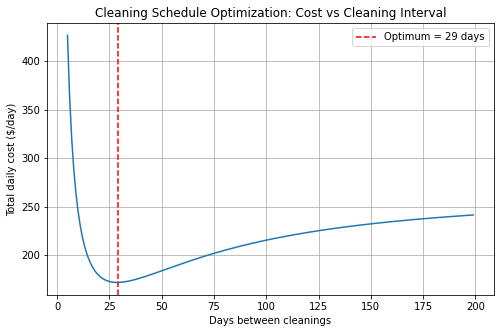

In [25]:
import matplotlib.pyplot as plt

T_range = range(5, 200)
costs = [cycle_daily_cost(T) for T in T_range]

plt.figure(figsize=(8,5))
plt.plot(list(T_range), costs)
plt.axvline(best_interval, color='red', linestyle='--', label=f'Optimum = {best_interval} days')
plt.xlabel('Days between cleanings')
plt.ylabel('Total daily cost ($/day)')
plt.title('Cleaning Schedule Optimization: Cost vs Cleaning Interval')
plt.legend()
plt.grid(True)
plt.savefig('velocity_optimization.png', dpi=150, bbox_inches='tight')
plt.show()